In [35]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent
import pandas as pd
vol_csv = pd.read_csv(BASE_DIR / "Tree_Modelling" / "VOLUME_DATASET.csv")
print(vol_csv.head())

   Unnamed: 0  OBJECTID          X          Y           LATIN_NAME  \
0         130  26609482  358778.42  173631.65       Betula pendula   
1         131  26609483  358769.66  173620.75        Betula utilis   
2         391  26609746  359249.26  173476.59  Acer platanoides cv   
3         392  26609747  359262.25  173477.53  Acer platanoides cv   
4         393  26609748  359276.98  173478.16  Acer platanoides cv   

    COMMON_NAME       FULL_COMMON_NAME         TREE_SPECIES   DBH tree_group  \
0  Silver Birch           Silver birch       Betula pendula  0.06  deciduous   
1         Birch        Himalayan birch        Betula utilis  0.32  deciduous   
2         Maple  Norway maple cultivar  Acer platanoides cv  0.50  deciduous   
3         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   
4         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   

   CROWN_AREA_COMPLETE  CROWN_VOLUME  
0             3.593897      8.579590  
1            10.0000

In [36]:

df_sensor = pd.read_csv(BASE_DIR / "site_outputs" / "site_203.csv")
print(df_sensor)

      SITE_ID   EASTING  NORTHING   NOX        DATE_TIME_STR
0         203  361178.0  171566.0   7.0  2023-01-01 00:00:00
1         203  361178.0  171566.0   7.0  2023-01-01 01:00:00
2         203  361178.0  171566.0   9.0  2023-01-01 02:00:00
3         203  361178.0  171566.0  10.0  2023-01-01 03:00:00
4         203  361178.0  171566.0   8.0  2023-01-01 04:00:00
...       ...       ...       ...   ...                  ...
8755      203  361178.0  171566.0  11.0  2023-12-31 19:00:00
8756      203  361178.0  171566.0  14.0  2023-12-31 20:00:00
8757      203  361178.0  171566.0  11.0  2023-12-31 21:00:00
8758      203  361178.0  171566.0  10.0  2023-12-31 22:00:00
8759      203  361178.0  171566.0   7.0  2023-12-31 23:00:00

[8760 rows x 5 columns]


In [37]:
import numpy as np

# Define your sensor location and the radius
SENSOR_X = 361178  # Replace with your sensor's Easting
SENSOR_Y = 171566  # Replace with your sensor's Northing
radius = 300.0       # meters

# Calculate the Euclidean distance for all rows simultaneously (vectorized for speed)
distances = np.sqrt((vol_csv['X'] - SENSOR_X)**2 + (vol_csv['Y'] - SENSOR_Y)**2)

# Filter the dataframe to only include trees within the radius
nearby_trees = vol_csv[distances <= radius].copy()

# Add the calculated distance as a new column
nearby_trees['DISTANCE_TO_SENSOR'] = distances[distances <= radius]

print(f"Found {len(nearby_trees)} trees within {radius}m of the sensor.")
# print(nearby_trees.head())

nearby_trees.to_csv('SENSOR_ID_203.csv')

Found 111 trees within 300.0m of the sensor.


In [38]:
print(nearby_trees)

      Unnamed: 0  OBJECTID          X          Y             LATIN_NAME  \
26          1559  26610931  361162.02  171571.83    Ulmus 'New Horizon'   
27          1560  26610932  361173.40  171565.53    Ulmus 'New Horizon'   
257         8362  26617862  361387.16  171550.54       Carpinus betulus   
972        41167  26650958  361175.90  171349.97  Platanus x acerifolia   
973        41168  26650959  361181.33  171355.10       Acer platanoides   
...          ...       ...        ...        ...                    ...   
1075       41338  26651129  361187.06  171388.23          Ginkgo biloba   
1076       41339  26651130  361013.09  171456.20       Parrotia persica   
1077       41397  26651188  361065.99  171351.38          Juglans regia   
1078       41398  26651189  361040.75  171319.91          Juglans regia   
1079       41399  26651190  361083.19  171373.37          Juglans regia   

     COMMON_NAME    FULL_COMMON_NAME           TREE_SPECIES       DBH  \
26           Elm  Elm ' Ne

In [39]:
df_wind = pd.read_csv('../Wind Data/clean_2023 (1).csv')
wind_subset = df_wind[['mean_wind_speed', 'mean_wind_dir']]

print(wind_subset)

      mean_wind_speed  mean_wind_dir
0                11.0          210.0
1                11.0          210.0
2                10.0          210.0
3                 9.0          200.0
4                 8.0          190.0
...               ...            ...
8746             19.0          240.0
8747             20.0          240.0
8748             19.0          240.0
8749             19.0          240.0
8750             18.0          240.0

[8751 rows x 2 columns]


## Sunlight and seasonality integration

This section calculates hourly sunlight and leaf multipliers, then applies them inside the geometric sink model.

In [40]:
# ============================================================
# Sunlight + seasonality multipliers for the selected sensor
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# Adjust only this path if needed
sun_path = Path('../sunrise and sunset data/bristol_sun_2023.csv')

sun = pd.read_csv(sun_path)

# --- 1) Prepare hourly sensor timestamps ---
# The sensor dataset contains the hourly DATE_TIME used to align everything.
df_sensor["DATE_TIME_STR"] = pd.to_datetime(df_sensor["DATE_TIME_STR"], errors="coerce")
df_sensor = df_sensor.dropna(subset=["DATE_TIME_STR"]).copy()

# Clip to 2023 because this is the year covered by the sunlight/wind data.
df_sensor_2023 = df_sensor[
    (df_sensor["DATE_TIME_STR"] >= "2023-01-01") &
    (df_sensor["DATE_TIME_STR"] < "2024-01-01")
].copy()

df_sensor_2023["date"] = df_sensor_2023["DATE_TIME_STR"].dt.normalize()
df_sensor_2023["day_of_year"] = df_sensor_2023["DATE_TIME_STR"].dt.dayofyear
df_sensor_2023["month"] = df_sensor_2023["DATE_TIME_STR"].dt.month
df_sensor_2023["hour"] = df_sensor_2023["DATE_TIME_STR"].dt.hour

# --- 2) Prepare sunrise/sunset data ---
sun["date"] = pd.to_datetime(sun["date"], errors="coerce").dt.normalize()

sun["Sunrise_clean"] = (
    sun["Sunrise/Sunset Sunrise Sunrise"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)

sun["Sunset_clean"] = (
    sun["Sunrise/Sunset Sunset Sunset"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)

sun["sunrise_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunrise_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

sun["sunset_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunset_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

# --- 3) Daylight fraction per sensor hour ---
hourly_context = df_sensor_2023.merge(
    sun[["date", "sunrise_dt", "sunset_dt"]],
    on="date",
    how="left"
)

hourly_context["hour_start"] = hourly_context["DATE_TIME_STR"]
hourly_context["hour_end"] = hourly_context["DATE_TIME_STR"] + pd.Timedelta(hours=1)

def daylight_fraction(row):
    start = row["hour_start"]
    end = row["hour_end"]
    sunrise = row["sunrise_dt"]
    sunset = row["sunset_dt"]

    if pd.isna(sunrise) or pd.isna(sunset):
        return np.nan

    # Completely dark
    if end <= sunrise or start >= sunset:
        return 0.0

    # Fully daylight
    if start >= sunrise and end <= sunset:
        return 1.0

    # Partial daylight during sunrise hour
    if start < sunrise < end:
        return (end - sunrise).total_seconds() / 3600

    # Partial daylight during sunset hour
    if start < sunset < end:
        return (sunset - start).total_seconds() / 3600

    return 0.0

hourly_context["sun_multiplier"] = hourly_context.apply(daylight_fraction, axis=1)

# --- 4) Leaf seasonality setup for nearby trees ---
nearby_trees["COMMON_NAME"] = nearby_trees["COMMON_NAME"].astype(str).str.strip()

evergreens = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

leaf_periods = {
    "Lime": (4, 10), "Cherry": (4, 9), "Maple": (5, 10), "Ash": (5, 10),
    "Sycamore": (5, 10), "Plane": (5, 10), "Oak": (5, 11), "Silver Birch": (4, 9),
    "Hawthorn": (4, 10), "Apple": (5, 10), "Field Maple": (5, 10), "Horse Chestnut": (4, 9),
    "Alder": (4, 10), "Hornbeam": (4, 11), "Whitebeam": (5, 10), "Rowan": (5, 9),
    "Poplar": (4, 9), "Beech": (5, 11), "Willow": (4, 10), "Plum": (4, 10)
}

default_deciduous_period = (4, 10)

def get_leaf_period(name):
    if name in evergreens:
        return (1, 12)
    return leaf_periods.get(name, default_deciduous_period)

nearby_trees[["leaf_start_month", "leaf_end_month"]] = nearby_trees["COMMON_NAME"].apply(
    lambda x: pd.Series(get_leaf_period(x))
)

nearby_trees["is_evergreen"] = nearby_trees["COMMON_NAME"].isin(evergreens)

month_mid_doy = {
    1: 15, 2: 46, 3: 74, 4: 105, 5: 135, 6: 166,
    7: 196, 8: 227, 9: 258, 10: 288, 11: 319, 12: 349
}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def leaf_multiplier(day_of_year, start_month, end_month, evergreen=False, ramp_days=30):
    if pd.isna(start_month) or pd.isna(end_month):
        return np.nan

    if evergreen:
        return 1.0

    start_doy = month_mid_doy[int(start_month)]
    end_doy = month_mid_doy[int(end_month)]

    # 30-day ramp: smooth leaf-on and leaf-off transition
    steepness = ramp_days / 6
    up = sigmoid((day_of_year - start_doy) / steepness)
    down = 1 - sigmoid((day_of_year - end_doy) / steepness)

    return float(up * down)

print("Hourly context rows:", len(hourly_context))
print("Sun multiplier range:", hourly_context["sun_multiplier"].min(), "to", hourly_context["sun_multiplier"].max())
print("Nearby trees:", len(nearby_trees))
print("Evergreen trees nearby:", nearby_trees["is_evergreen"].sum())

Hourly context rows: 8808
Sun multiplier range: 0.0 to 1.0
Nearby trees: 111
Evergreen trees nearby: 7


In [41]:
import pandas as pd
import numpy as np

def calculate_sensor_geometric_sink(
    sensor_x,
    sensor_y,
    tree_df,
    U,
    wind_dir_deg,
    sun_multiplier,
    day_of_year,
    T_max=900,
    D=0.2,
    max_distance=300,
    ramp_days=30
):
    """
    Calculates the total hourly geometric sink factor G_h at a sensor.

    The original crown metrics are adjusted per hour using:
        effective_crown_volume = CROWN_VOLUME * leaf_multiplier * sun_multiplier
        effective_crown_area   = CROWN_AREA_COMPLETE * leaf_multiplier

    Notes:
    - sunlight is applied to volume/uptake strength, not to sigma directly, because at night
      the effective volume becomes zero and the tree contributes no uptake.
    - crown area is seasonally adjusted because leaf-on/leaf-off changes the active canopy.
    """

    # If there is no daylight, uptake contribution is zero for the hour.
    if pd.isna(sun_multiplier) or sun_multiplier <= 0:
        return 0.0

    # Wind convention: meteorological degrees: 0 = North, 90 = East.
    # This matches the plotting function below.
    theta = np.radians(wind_dir_deg)
    u_wind = U * np.sin(theta)  # Easting component
    v_wind = U * np.cos(theta)  # Northing component

    # Dynamic time-stepping
    dt = 1.0 if U <= 1.0 else 1.0 / U

    # Cut off once the plume is likely beyond the sensor radius/map.
    dynamic_T_max = T_max
    if U > 0.1:
        dynamic_T_max = min(T_max, max_distance / U)

    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    G_total = 0.0

    for row in tree_df.itertuples(index=False):
        leaf_mult = leaf_multiplier(
            day_of_year=day_of_year,
            start_month=row.leaf_start_month,
            end_month=row.leaf_end_month,
            evergreen=row.is_evergreen,
            ramp_days=ramp_days
        )

        if pd.isna(leaf_mult) or leaf_mult <= 0:
            continue

        # Apply seasonality and sunlight to the crown variables.
        effective_area = row.CROWN_AREA_COMPLETE * leaf_mult
        effective_volume = row.CROWN_VOLUME * leaf_mult * sun_multiplier

        if effective_area <= 0 or effective_volume <= 0:
            continue

        tx = row.X
        ty = row.Y

        # Initial canopy spread from effective crown area.
        radius = np.sqrt(effective_area / np.pi)
        sigma_0 = radius / 2.15

        puff_x = tx + (u_wind * t_array)
        puff_y = ty + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)

        dist_sq = (sensor_x - puff_x)**2 + (sensor_y - puff_y)**2

        coeff = (effective_volume * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))

        G_total += np.sum(coeff * exponent)

    return G_total

In [43]:
# ============================================================
# Generate hourly G_h predictions using wind + sunlight + leaves
# ============================================================

# Make sure wind and hourly sensor/sun data align row-by-row.
# If both are complete 2023 hourly series, this keeps the first n shared rows.
n = min(len(wind_subset), len(hourly_context))

wind_2023 = wind_subset.iloc[:n].reset_index(drop=True).copy()
hourly_context_model = hourly_context.iloc[:n].reset_index(drop=True).copy()

hourly_G_predictions = []

for wind_row, time_row in zip(
    wind_2023.itertuples(index=False),
    hourly_context_model.itertuples(index=False)
):
    G_h = calculate_sensor_geometric_sink(
        sensor_x=SENSOR_X,
        sensor_y=SENSOR_Y,
        tree_df=nearby_trees,
        U=wind_row.mean_wind_speed,
        wind_dir_deg=wind_row.mean_wind_dir,
        sun_multiplier=time_row.sun_multiplier,
        day_of_year=time_row.day_of_year
    )

    hourly_G_predictions.append(G_h)

G_df = hourly_context_model[["DATE_TIME_STR", "NOX"]].copy() if "NOX" in hourly_context_model.columns else hourly_context_model[["DATE_TIME_STR"]].copy()
G_df["mean_wind_speed"] = wind_2023["mean_wind_speed"].values
G_df["mean_wind_dir"] = wind_2023["mean_wind_dir"].values
G_df["sun_multiplier"] = hourly_context_model["sun_multiplier"].values
G_df["G_h_effective"] = hourly_G_predictions

print(G_df.head())
print(G_df["G_h_effective"].describe())

G_df.to_csv("check_G_effective_2023.csv", index=False)

        DATE_TIME_STR   NOX  mean_wind_speed  mean_wind_dir  sun_multiplier  \
0 2023-01-01 00:00:00   7.0             11.0          210.0             0.0   
1 2023-01-01 01:00:00   7.0             11.0          210.0             0.0   
2 2023-01-01 02:00:00   9.0             10.0          210.0             0.0   
3 2023-01-01 03:00:00  10.0              9.0          200.0             0.0   
4 2023-01-01 04:00:00   8.0              8.0          190.0             0.0   

   G_h_effective  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  
count     8.751000e+03
mean      5.305449e+00
std       2.447917e+01
min       0.000000e+00
25%       0.000000e+00
50%      5.788742e-203
75%       3.133840e-07
max       6.339560e+02
Name: G_h_effective, dtype: float64


Night-time rows: 3878
Max night-time G_h: 0.0
Day-time rows: 4825
Max day-time G_h: 633.2863868277032


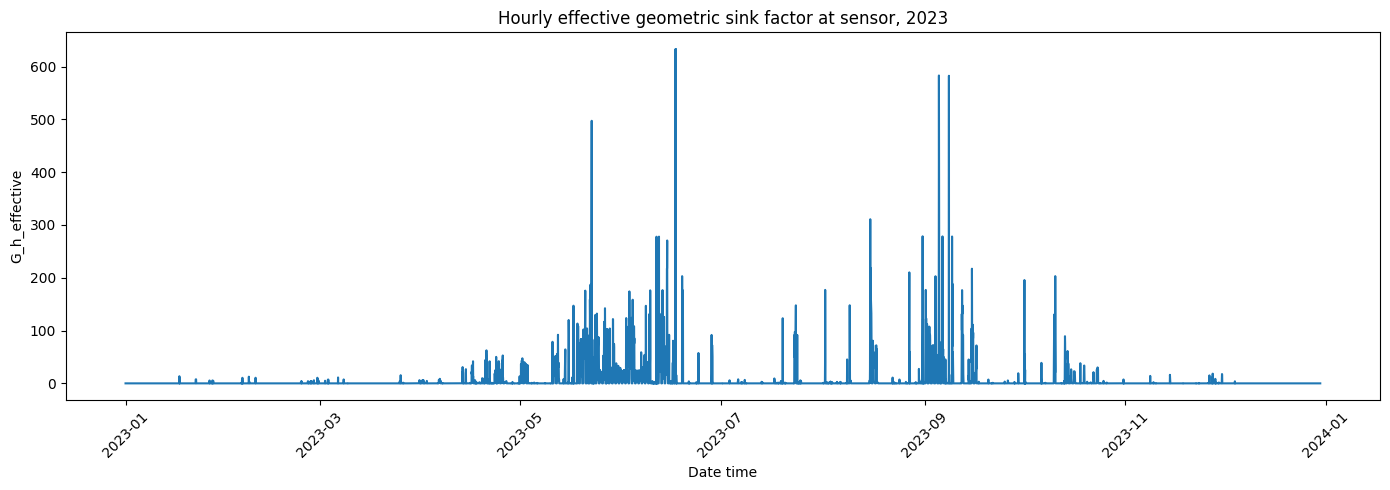

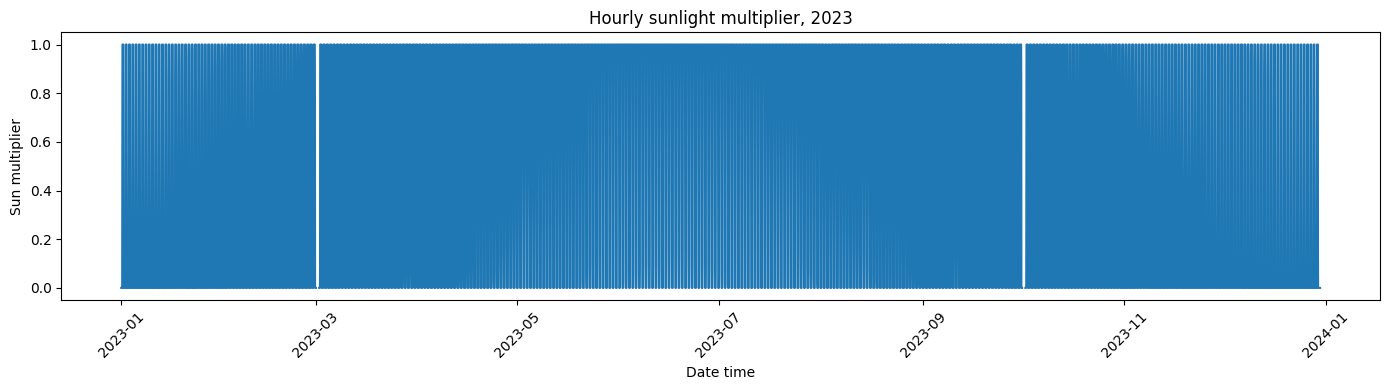

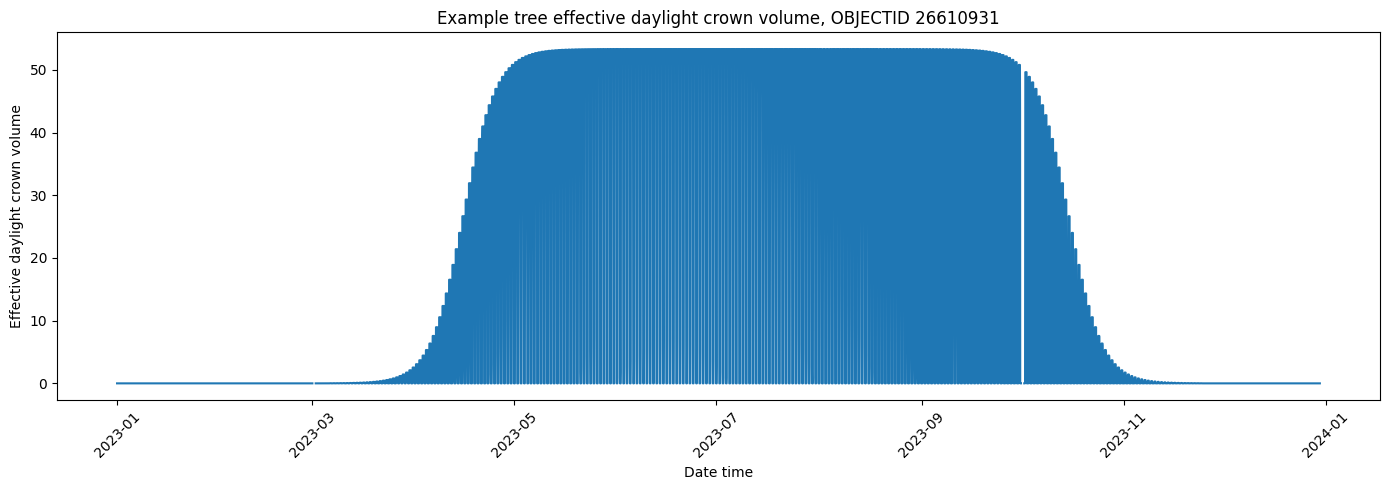

Example tree:
OBJECTID                26610931
COMMON_NAME                  Elm
CROWN_AREA_COMPLETE         10.0
CROWN_VOLUME           53.333333
is_evergreen               False
Name: 26, dtype: object


In [ ]:
# ============================================================
# Quick checks: has the integration worked?
# ============================================================

import matplotlib.pyplot as plt

# 1) Night-time G_h should be zero because sun_multiplier = 0.
night_check = G_df.loc[G_df["sun_multiplier"] == 0, "G_h_effective"]
print("Night-time rows:", len(night_check))
print("Max night-time G_h:", night_check.max() if len(night_check) else "No night rows found")

# 2) Day-time G_h should contain positive values if nearby trees + wind geometry contribute.
day_check = G_df.loc[G_df["sun_multiplier"] > 0, "G_h_effective"]
print("Day-time rows:", len(day_check))
print("Max day-time G_h:", day_check.max() if len(day_check) else "No day rows found")

# 3) Plot annual hourly G_h for 2023.
plt.figure(figsize=(14, 5))
plt.plot(G_df["DATE_TIME"], G_df["G_h_effective"])
plt.title("Hourly effective geometric sink factor at sensor, 2023")
plt.xlabel("Date time")
plt.ylabel("G_h_effective")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4) Plot sunlight multiplier to check sunrise/sunset behaviour.
plt.figure(figsize=(14, 4))
plt.plot(G_df["DATE_TIME"], G_df["sun_multiplier"])
plt.title("Hourly sunlight multiplier, 2023")
plt.xlabel("Date time")
plt.ylabel("Sun multiplier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Example tree effective volume across 2023.
example_tree = nearby_trees.iloc[0].copy()

example_leaf = hourly_context_model["day_of_year"].apply(
    lambda doy: leaf_multiplier(
        day_of_year=doy,
        start_month=example_tree["leaf_start_month"],
        end_month=example_tree["leaf_end_month"],
        evergreen=example_tree["is_evergreen"]
    )
)

example_effective_volume = (
    example_tree["CROWN_VOLUME"] *
    example_leaf *
    hourly_context_model["sun_multiplier"]
)

plt.figure(figsize=(14, 5))
plt.plot(hourly_context_model["DATE_TIME"], example_effective_volume)
plt.title(f"Example tree effective daylight crown volume, OBJECTID {example_tree['OBJECTID']}")
plt.xlabel("Date time")
plt.ylabel("Effective daylight crown volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Example tree:")
print(example_tree[["OBJECTID", "COMMON_NAME", "CROWN_AREA_COMPLETE", "CROWN_VOLUME", "is_evergreen"]])

Generating map for hour index 0...
Wind Conditions: 11.0 m/s towards 210.0°


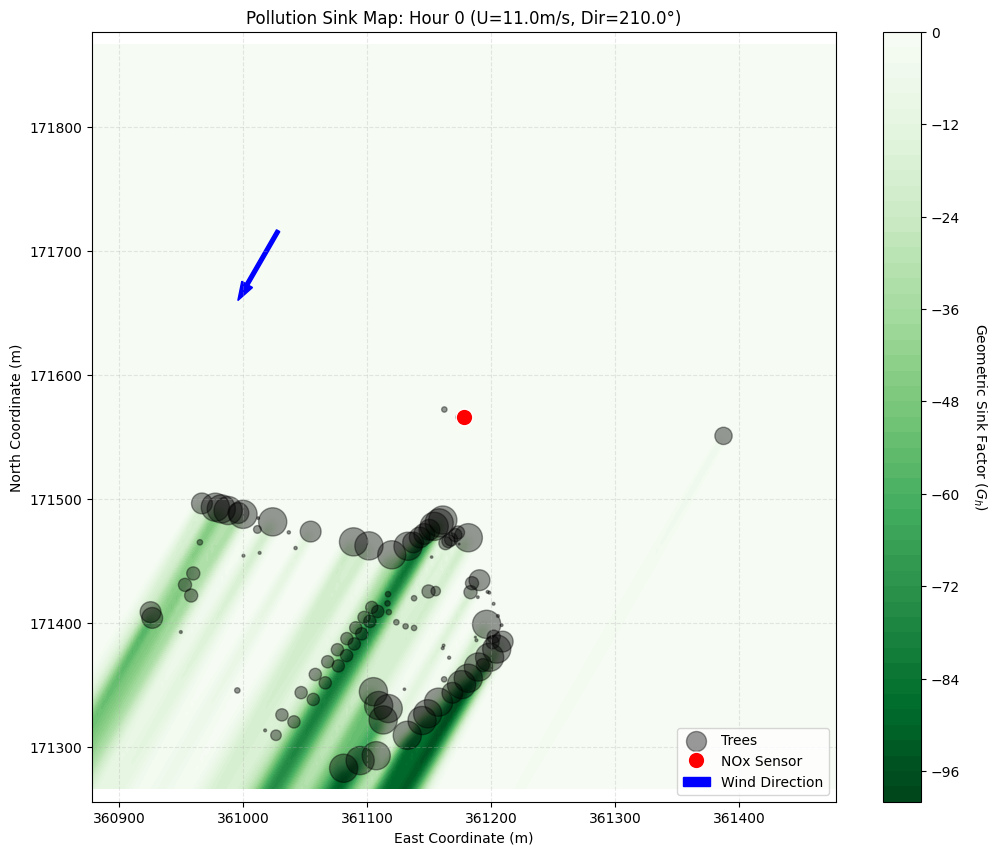

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hourly_wakes(hour_index, wind_df, tree_df, sensor_x, sensor_y):
    """
    Generates a map for a single hour's wind conditions using 3D broadcasting.
    """
    # 1. Extract Wind Data for the chosen hour
    row = wind_df.iloc[hour_index]
    U = row.mean_wind_speed
    direction = row.mean_wind_dir
    
    # 2. Setup the Spatial Grid (300m radius around sensor)
    # Increase resolution (e.g., 300) for smoother plots, decrease for speed
    resolution = 150 
    x_range = np.linspace(sensor_x - 300, sensor_x + 300, resolution)
    y_range = np.linspace(sensor_y - 300, sensor_y + 300, resolution)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    
    # Add 3rd dimension for time broadcasting (Y, X, T)
    X_3d = X_grid[..., np.newaxis]
    Y_3d = Y_grid[..., np.newaxis]
    
    # 3. Physics & Continuity Parameters
    D = 0.2
    T_max = 900
    dt = 1.0 if U <= 1.0 else 1.0 / U
    # Only calculate puffs that stay within the map bounds
    dynamic_T_max = min(T_max, 400 / U) if U > 0.1 else T_max
    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    
    # 4. Wind Vector Convention
    # Default: Meteorological (0=North, 90=East)
    # If your data is 0=East, swap sin and cos.
    theta = np.radians(direction)
    u_wind = U * np.sin(theta) # East component
    v_wind = U * np.cos(theta) # North component

    G_map = np.zeros_like(X_grid, dtype=float)

    print(f"Generating map for hour index {hour_index}...")
    print(f"Wind Conditions: {U} m/s towards {direction}°")

    # 5. Superposition Loop
    for tree in tree_df.itertuples():
        # Canopy physics
        radius = np.sqrt(tree.CROWN_AREA_COMPLETE / np.pi)
        sigma_0 = radius / 2.15
        
        # Where are the puffs? (Center of each Gaussian over time)
        puff_x = tree.X + (u_wind * t_array)
        puff_y = tree.Y + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)
        
        # Distance squared: (Grid - Puff_Center)^2
        # Broadcasting handles the (Res, Res, 1) - (T) interaction
        dist_sq = (X_3d - puff_x)**2 + (Y_3d - puff_y)**2
        
        # Mass-conserved Gaussian Field
        coeff = (tree.CROWN_VOLUME * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))
        
        # Sum along time axis (axis=2) and add to map
        G_map += np.sum(coeff * exponent, axis=2)

    # 6. Plotting the Results
    plt.figure(figsize=(12, 10))
    
    # Flip G to negative for visual 'sink' intuition
    contour = plt.contourf(X_grid, Y_grid, -G_map, levels=60, cmap='Greens_r')
    cbar = plt.colorbar(contour)
    cbar.set_label('Geometric Sink Factor ($G_h$)', rotation=270, labelpad=20)
    
    # Plot trees - using crown area to scale marker size
    plt.scatter(tree_df.X, tree_df.Y, s=tree_df.CROWN_AREA_COMPLETE * 1.5, 
                color='black', alpha=0.4, label='Trees')
    
    # Plot Sensor
    plt.plot(sensor_x, sensor_y, 'ro', markersize=12, label='NOx Sensor', markeredgecolor='white')
    
    # Visual Wind Arrow (relative to sensor)
    arrow_len = 50
    plt.arrow(sensor_x - 150, sensor_y + 150, 
              arrow_len * np.sin(theta), arrow_len * np.cos(theta), 
              width=3, head_width=10, color='blue', label='Wind Direction')

    plt.title(f"Pollution Sink Map: Hour {hour_index} (U={U}m/s, Dir={direction}°)")
    plt.xlabel("East Coordinate (m)")
    plt.ylabel("North Coordinate (m)")
    plt.legend(loc='lower right')
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# --- RUN THE PLOT ---
# Pick any index from your wind_subset
plot_hourly_wakes(hour_index=0, 
                  wind_df=wind_subset, 
                  tree_df=nearby_trees, 
                  sensor_x=SENSOR_X, 
                  sensor_y=SENSOR_Y)